# Práctica 3 — Aprendizaje por Refuerzo en Pendulum-v1

**Modelos Avanzados de Aprendizaje Automático II** · Curso 2025/2026

En este notebook se implementan tres algoritmos tabulares de control para el entorno
[`Pendulum-v1`](https://gymnasium.farama.org/environments/classic_control/pendulum/) de Gymnasium:

1. **Monte Carlo control ε-soft on-policy**
2. **SARSA**
3. **Q-Learning**

El entorno tiene observación continua `(cos θ, sin θ, θ̇)` y acción continua (par en `[-2, 2]`),
por lo que es necesario discretizar tanto el estado como la acción para usar estos algoritmos
tabulares. Se utiliza una rejilla de `20 × 20` para el estado y 9 acciones equiespaciadas.

Al final del notebook se realizan las comparativas y el experimento de robustez ante ruido
en la acción (pregunta 5 del enunciado).


## 1. Setup

Se crea el entorno y se fijan semillas. Por defecto `Pendulum-v1` trunca cada episodio a
200 pasos con `dt = 0.05 s`, es decir 10 s exactos, tal y como pide el enunciado.


In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

np.random.seed(0)

env = gym.make("Pendulum-v1")
print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)
print("Pasos por episodio:", env.spec.max_episode_steps, " (10 s con dt=0.05)")


Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space:      Box(-2.0, 2.0, (1,), float32)
Pasos por episodio: 200  (10 s con dt=0.05)


## 2. Discretización de estados y acciones

- **Estado**: la observación es `(cos θ, sin θ, θ̇)`. Reconstruimos el ángulo
  `θ = atan2(sin θ, cos θ) ∈ [-π, π]` y discretizamos `θ` en `N_THETA = 20` intervalos
  y la velocidad angular `θ̇` (acotada a `[-8, 8]` por el entorno) en `N_DOT = 20`.
- **Acción**: el torque continuo `[-2, 2]` se discretiza en `N_A = 9` valores
  equiespaciados (incluyendo los extremos).

El espacio resultante tiene `20 × 20 × 9 = 3600` pares estado-acción, lo bastante
pequeño para converger en pocos miles de episodios y lo bastante fino para distinguir
estados cualitativamente diferentes (péndulo arriba/abajo, girando rápido/despacio).


In [6]:
N_THETA = 20
N_DOT   = 20
N_A     = 9

THETA_BINS = np.linspace(-np.pi, np.pi, N_THETA + 1)
DOT_BINS   = np.linspace(-8.0,    8.0, N_DOT   + 1)
ACCIONES   = np.linspace(-2.0,    2.0, N_A)

def discretiza_estado(obs):
    cos_t, sin_t, dot = obs
    theta = np.arctan2(sin_t, cos_t)
    i_theta = int(np.clip(np.digitize(theta, THETA_BINS) - 1, 0, N_THETA - 1))
    i_dot   = int(np.clip(np.digitize(dot,   DOT_BINS)   - 1, 0, N_DOT   - 1))
    return (i_theta, i_dot)

def accion_continua(idx_a):
    return np.array([ACCIONES[idx_a]], dtype=np.float32)

def epsilon_greedy(Q, s, eps):
    if np.random.random() < eps:
        return np.random.randint(N_A)
    return int(np.argmax(Q[s]))


### Sanity checks

Verificamos que el entorno y la discretización funcionan correctamente.


In [7]:
# Episodio aleatorio: comprobamos longitud y rango de retornos
obs, _ = env.reset(seed=0)
n_pasos, G = 0, 0.0
while True:
    obs, r, term, trunc, _ = env.step(env.action_space.sample())
    G += r; n_pasos += 1
    if term or trunc: break
print(f"Episodio aleatorio: {n_pasos} pasos, retorno = {G:.2f}")

# Discretización: para 5000 obs aleatorias, los índices deben estar dentro de rango
ok = True
for _ in range(5000):
    o = env.observation_space.sample()
    i, j = discretiza_estado(o)
    if not (0 <= i < N_THETA and 0 <= j < N_DOT):
        ok = False; break
print("Discretización dentro de rango:", ok)


Episodio aleatorio: 200 pasos, retorno = -999.57
Discretización dentro de rango: True


## 3. Hiperparámetros

Se eligen los **mismos hiperparámetros base para los tres algoritmos** para que la
comparativa sea justa:

| Parámetro | Valor | Justificación |
|-----------|------:|---------------|
| `GAMMA`   | 0.99  | Pendulum es de horizonte largo (200 pasos por episodio); valores menores penalizan demasiado el equilibrio sostenido. |
| `ALPHA`   | 0.1   | Estándar en TD tabular (mismo valor que el notebook 8). Valores mayores oscilan; menores convergen muy lento. |
| `EPSILON` | 0.1   | Mantiene exploración suficiente sin romper la política. |
| `NUM_EPISODIOS` | 5000 | Suficiente para observar convergencia con discretización 20×20×9. |


In [8]:
GAMMA         = 0.99
ALPHA         = 0.1
EPSILON       = 0.1
NUM_EPISODIOS = 5000


## 4. Monte Carlo control (ε-soft on-policy)

Sigue el esquema clásico (Sutton & Barto, capítulo 5):

1. Genera un episodio completo siguiendo la política ε-soft derivada de `Q`.
2. Recorre el episodio hacia atrás calculando el retorno `G_t = r_{t+1} + γ G_{t+1}`.
3. Actualiza `Q(s,a)` como **promedio incremental** de los retornos observados
   (`Q ← Q + (G - Q) / N`), evitando almacenar listas anidadas.

Se usa la versión **every-visit** (todas las apariciones de `(s,a)` en el episodio
contribuyen al promedio); es algo más sencilla que first-visit y converge igual.


In [9]:
def mc_control(num_episodios=NUM_EPISODIOS, epsilon=EPSILON, gamma=GAMMA, env=env, seed=0):
    np.random.seed(seed)
    Q = np.zeros((N_THETA, N_DOT, N_A))
    N = np.zeros((N_THETA, N_DOT, N_A))
    retornos_episodio = []

    for ep in tqdm(range(num_episodios), desc="MC"):
        # 1. Generar episodio siguiendo política ε-soft derivada de Q
        obs, _ = env.reset()
        s = discretiza_estado(obs)
        recorrido = []
        retorno = 0.0
        done = False
        while not done:
            a = epsilon_greedy(Q, s, epsilon)
            obs, r, term, trunc, _ = env.step(accion_continua(a))
            recorrido.append((s, a, r))
            retorno += r
            s = discretiza_estado(obs)
            done = term or trunc
        retornos_episodio.append(retorno)

        # 2-3. Recorrer hacia atrás y actualizar Q como promedio incremental (every-visit)
        G = 0.0
        for s_t, a_t, r_t in reversed(recorrido):
            G = r_t + gamma * G
            N[s_t][a_t] += 1
            Q[s_t][a_t] += (G - Q[s_t][a_t]) / N[s_t][a_t]

    return Q, retornos_episodio


## 5. SARSA

Algoritmo on-policy con actualización TD(0):

`Q(S,A) ← Q(S,A) + α · [R + γ · Q(S', A') − Q(S,A)]`

donde `A'` se elige con la política ε-greedy actual. Por ser on-policy, la `Q` que
aprende refleja el comportamiento real del agente (incluida la exploración).


In [10]:
def sarsa(num_episodios=NUM_EPISODIOS, alpha=ALPHA, epsilon=EPSILON, gamma=GAMMA, env=env, seed=0):
    np.random.seed(seed)
    Q = np.zeros((N_THETA, N_DOT, N_A))
    retornos_episodio = []

    for ep in tqdm(range(num_episodios), desc="SARSA"):
        obs, _ = env.reset()
        S = discretiza_estado(obs)
        A = epsilon_greedy(Q, S, epsilon)
        retorno = 0.0
        done = False

        while not done:
            obs, R, term, trunc, _ = env.step(accion_continua(A))
            retorno += R
            S_prime = discretiza_estado(obs)
            done = term or trunc

            if done:
                Q[S][A] += alpha * (R - Q[S][A])
            else:
                A_prime = epsilon_greedy(Q, S_prime, epsilon)
                td = R + gamma * Q[S_prime][A_prime] - Q[S][A]
                Q[S][A] += alpha * td
                S, A = S_prime, A_prime

        retornos_episodio.append(retorno)

    return Q, retornos_episodio


## 6. Q-Learning

Algoritmo off-policy: la actualización usa el `max` sobre la siguiente acción,
no la acción que se va a ejecutar realmente:

`Q(S,A) ← Q(S,A) + α · [R + γ · max_{a'} Q(S', a') − Q(S,A)]`

Esto suele converger a una política más optimista que SARSA, pero puede ser más
arriesgada durante el aprendizaje.


In [11]:
def q_learning(num_episodios=NUM_EPISODIOS, alpha=ALPHA, epsilon=EPSILON, gamma=GAMMA, env=env, seed=0):
    np.random.seed(seed)
    Q = np.zeros((N_THETA, N_DOT, N_A))
    retornos_episodio = []

    for ep in tqdm(range(num_episodios), desc="Q-Learning"):
        obs, _ = env.reset()
        S = discretiza_estado(obs)
        retorno = 0.0
        done = False

        while not done:
            A = epsilon_greedy(Q, S, epsilon)
            obs, R, term, trunc, _ = env.step(accion_continua(A))
            retorno += R
            S_prime = discretiza_estado(obs)
            done = term or trunc

            if done:
                Q[S][A] += alpha * (R - Q[S][A])
            else:
                td = R + gamma * np.max(Q[S_prime]) - Q[S][A]
                Q[S][A] += alpha * td
                S = S_prime

        retornos_episodio.append(retorno)

    return Q, retornos_episodio


## 7. Función de evaluación determinista

Simula `num_episodios` siguiendo la **política greedy** derivada de `Q` (sin exploración)
y devuelve la media y desviación estándar del retorno. Acepta un parámetro `ruido_p`
opcional que reemplaza la acción del agente por `[-2.0]` o `[2.0]` con probabilidad
`p` (para el experimento de robustez).


In [12]:
def evalua_politica(Q, num_episodios=100, ruido_p=0.0, env=env, seed=42):
    rng = np.random.default_rng(seed)
    retornos = []
    for i in range(num_episodios):
        obs, _ = env.reset(seed=seed + i)
        s = discretiza_estado(obs)
        G = 0.0
        done = False
        while not done:
            a = int(np.argmax(Q[s]))
            accion = accion_continua(a)
            if ruido_p > 0 and rng.random() < ruido_p:
                accion = np.array([rng.choice([-2.0, 2.0])], dtype=np.float32)
            obs, r, term, trunc, _ = env.step(accion)
            G += r
            s = discretiza_estado(obs)
            done = term or trunc
        retornos.append(G)
    return float(np.mean(retornos)), float(np.std(retornos)), retornos


## 8. Entrenamiento de los tres algoritmos

Se entrena cada algoritmo con los mismos hiperparámetros y la misma semilla.
La barra de progreso muestra el ritmo de cada uno.


In [13]:
Q_mc,    ret_mc    = mc_control()
Q_sarsa, ret_sarsa = sarsa()
Q_ql,    ret_ql    = q_learning()


Q-Learning: 100%|██████████| 5000/5000 [00:17<00:00, 290.71it/s]


## 9. Comparativa visual

### 9.1 Curvas de aprendizaje (media móvil de 100 episodios)


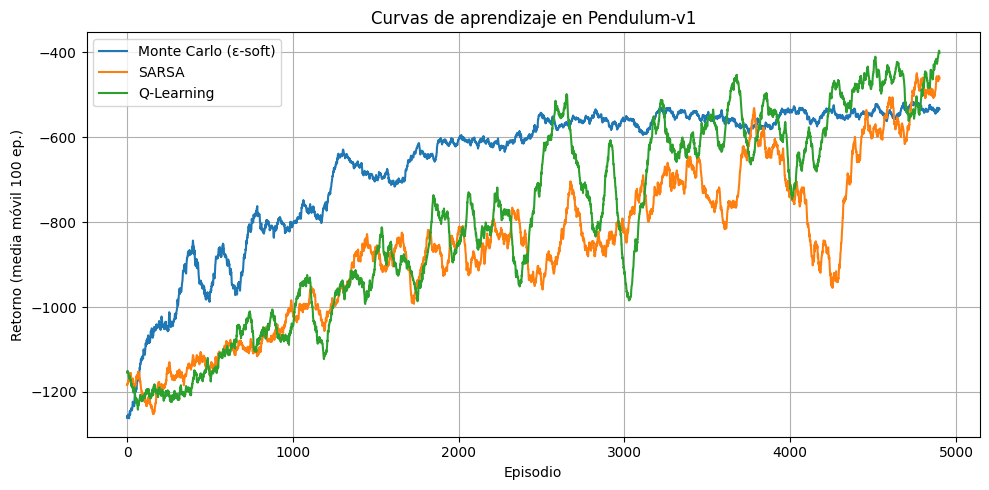

In [14]:
def media_movil(x, w=100):
    if len(x) < w:
        return np.array(x)
    c = np.cumsum(np.insert(x, 0, 0))
    return (c[w:] - c[:-w]) / w

plt.figure(figsize=(10, 5))
plt.plot(media_movil(ret_mc),    label="Monte Carlo (ε-soft)")
plt.plot(media_movil(ret_sarsa), label="SARSA")
plt.plot(media_movil(ret_ql),    label="Q-Learning")
plt.xlabel("Episodio")
plt.ylabel("Retorno (media móvil 100 ep.)")
plt.title("Curvas de aprendizaje en Pendulum-v1")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### 9.2 Heatmap de la política greedy

Para cada algoritmo se muestra el torque elegido por la política greedy en función
del estado discretizado `(θ, θ̇)`. El color codifica la magnitud y signo del torque.


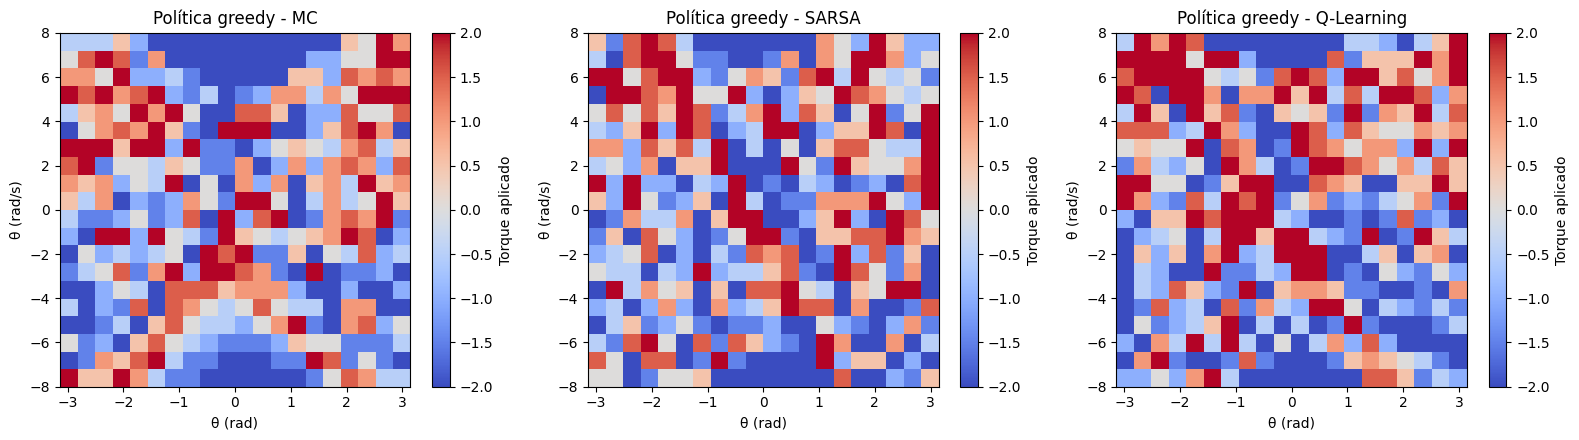

In [15]:
def politica_greedy(Q):
    return np.argmax(Q, axis=2)  # shape (N_THETA, N_DOT)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, Q, name in zip(axs, [Q_mc, Q_sarsa, Q_ql], ["MC", "SARSA", "Q-Learning"]):
    pol = ACCIONES[politica_greedy(Q)]
    im = ax.imshow(
        pol.T, origin="lower", aspect="auto", cmap="coolwarm",
        extent=[-np.pi, np.pi, -8, 8], vmin=-2, vmax=2,
    )
    ax.set_xlabel("θ (rad)")
    ax.set_ylabel("θ̇ (rad/s)")
    ax.set_title(f"Política greedy - {name}")
    plt.colorbar(im, ax=ax, label="Torque aplicado")
plt.tight_layout(); plt.show()


### 9.3 Tabla de retornos finales (política greedy)

Evaluamos cada política durante 100 episodios deterministas (sin exploración ni ruido).
Cuanto mayor (menos negativo) sea el retorno, mejor.


In [16]:
print("Evaluación con política GREEDY (sin ruido)")
print("-" * 50)
resultados_greedy = {}
for Q, name in [(Q_mc, "MC"), (Q_sarsa, "SARSA"), (Q_ql, "Q-Learning")]:
    m, s, _ = evalua_politica(Q, num_episodios=100, ruido_p=0.0)
    resultados_greedy[name] = (m, s)
    print(f"  {name:10s}: {m:8.2f} ± {s:6.2f}")


Evaluación con política GREEDY (sin ruido)
--------------------------------------------------
  MC        :  -499.42 ± 146.94
  SARSA     :  -504.26 ± 441.58
  Q-Learning:  -875.72 ± 303.98


## 10. Robustez ante perturbaciones (pregunta 5)

Se introduce ruido en la acción: con probabilidad `p = 0.05` la acción ejecutada se
sustituye por `[-2.0]` o `[2.0]` (par máximo en sentido aleatorio). Esto simula
fallos del actuador o perturbaciones externas.


In [17]:
print("Evaluación con ruido p=0.05 en la acción")
print("-" * 65)
print(f"  {'Algoritmo':10s} {'greedy':>10s} {'con ruido':>12s} {'Δ':>10s}")
print("-" * 65)
resultados_ruido = {}
for Q, name in [(Q_mc, "MC"), (Q_sarsa, "SARSA"), (Q_ql, "Q-Learning")]:
    m0, _, _ = evalua_politica(Q, num_episodios=100, ruido_p=0.0)
    m,  _, _ = evalua_politica(Q, num_episodios=100, ruido_p=0.05)
    resultados_ruido[name] = (m0, m)
    print(f"  {name:10s} {m0:10.2f} {m:12.2f} {m - m0:+10.2f}")


Evaluación con ruido p=0.05 en la acción
-----------------------------------------------------------------
  Algoritmo      greedy    con ruido          Δ
-----------------------------------------------------------------
  MC            -499.42      -518.48     -19.05
  SARSA         -504.26      -536.03     -31.77
  Q-Learning    -875.72      -831.69     +44.03


### 10.1 Mejora de la robustez: entrenar con ruido (domain randomization)

Una forma sencilla de hacer la política más robusta es **inyectar el mismo tipo de
ruido durante el entrenamiento**, de modo que el agente aprenda a recuperarse de
acciones inesperadas. Reentrenamos Q-Learning aplicando ruido con `p = 0.05` a las
acciones que se ejecutan en el entorno (la actualización usa la acción **realmente
ejecutada**, no la elegida por la política).


In [18]:
def q_learning_robusto(num_episodios=NUM_EPISODIOS, alpha=ALPHA, epsilon=EPSILON,
                       gamma=GAMMA, ruido_p=0.05, env=env, seed=0):
    np.random.seed(seed)
    Q = np.zeros((N_THETA, N_DOT, N_A))
    retornos_episodio = []

    for ep in tqdm(range(num_episodios), desc="Q-Learning robusto"):
        obs, _ = env.reset()
        S = discretiza_estado(obs)
        retorno = 0.0
        done = False

        while not done:
            A = epsilon_greedy(Q, S, epsilon)
            accion = accion_continua(A)
            # Ruido: con prob p sustituimos la acción por ±2
            if np.random.random() < ruido_p:
                accion = np.array([np.random.choice([-2.0, 2.0])], dtype=np.float32)
            obs, R, term, trunc, _ = env.step(accion)
            retorno += R
            S_prime = discretiza_estado(obs)
            done = term or trunc

            if done:
                Q[S][A] += alpha * (R - Q[S][A])
            else:
                td = R + gamma * np.max(Q[S_prime]) - Q[S][A]
                Q[S][A] += alpha * td
                S = S_prime

        retornos_episodio.append(retorno)

    return Q, retornos_episodio


Q_ql_rob, ret_ql_rob = q_learning_robusto()

m0, _, _ = evalua_politica(Q_ql_rob, num_episodios=100, ruido_p=0.0)
m,  _, _ = evalua_politica(Q_ql_rob, num_episodios=100, ruido_p=0.05)
print()
print("Q-Learning entrenado CON ruido p=0.05:")
print(f"  greedy:    {m0:.2f}")
print(f"  con ruido: {m:.2f}  (Δ={m - m0:+.2f})")
print()
print("Comparado con Q-Learning original (sin ruido en entrenamiento):")
m0o, mro = resultados_ruido["Q-Learning"]
print(f"  greedy:    {m0o:.2f}")
print(f"  con ruido: {mro:.2f}  (Δ={mro - m0o:+.2f})")


Q-Learning robusto: 100%|██████████| 5000/5000 [00:17<00:00, 290.54it/s]



Q-Learning entrenado CON ruido p=0.05:
  greedy:    -409.19
  con ruido: -462.37  (Δ=-53.18)

Comparado con Q-Learning original (sin ruido en entrenamiento):
  greedy:    -875.72
  con ruido: -831.69  (Δ=+44.03)


## 11. (Opcional) Renderizado visual

Para visualizar la política de Q-Learning en una ventana, ejecuta este bloque
**fuera del notebook** o en una sesión local con soporte gráfico:

```python
env_vis = gym.make("Pendulum-v1", render_mode="human")
obs, _ = env_vis.reset(seed=0)
s = discretiza_estado(obs)
done = False
while not done:
    a = int(np.argmax(Q_ql[s]))
    obs, r, term, trunc, _ = env_vis.step(accion_continua(a))
    s = discretiza_estado(obs)
    done = term or trunc
env_vis.close()
```


## 12. Resumen para el informe

A continuación se sintetizan los resultados que hay que volcar en el PDF (las
respuestas detalladas se redactan allí, no aquí):

1. **Discretización**: `θ` en 20 bins en `[-π, π]`, `θ̇` en 20 bins en `[-8, 8]`
   y torque en 9 valores equiespaciados en `[-2, 2]` (3600 pares estado-acción).
2. **Hiperparámetros**: `γ=0.99`, `α=0.1`, `ε=0.1`, 5000 episodios — ver tabla en §3.
3. **Mejor política determinista**: ver §9.3 (mayor retorno greedy).
4. **Mejor rendimiento durante el aprendizaje**: ver curva de §9.1
   (mayor retorno medio durante el entrenamiento).
5. **Robustez al ruido**: ver §10 (caída más pequeña Δ) y §10.1 (mejora con
   entrenamiento ruidoso).
